# Сравнение претрейнов по downstream-задачам

Цель — сравнить не отдельные абсолютные числа, а **место каждого претрейна среди остальных**.
Так RMSE, accuracy и угловые метрики становятся сопоставимыми, не требуя произвольного
масштабирования.

Структура:

1. force estimation;
2. pose estimation;
3. object classification;
4. профиль от локальной к глобальной информации;
5. общий топ.

Ноутбук каждый раз заново сканирует `experiments/downstream_*`. Для каждого
претрейн-чекпойнта берётся самый свежий завершённый запуск каждой задачи;
другие запуски сохраняются в отчёте о сборе. Основное множество — только
методы с претрейном. Референсы показаны отдельно и не влияют на места претрейнов.

## Как считаются ранги

- Для RMSE меньше — лучше; для accuracy больше — лучше.
- Ничьи получают средний ранг.
- **Force rank**: ранг общего `force RMSE`.
- **Pose rank**: сначала поровну объединяются translation (`x`, `y`) и rotation (`θ`);
  внутри каждой части RMSE и accuracy имеют одинаковый вес.
- **Object rank**: ранг accuracy.
- **Overall rank**: среднее трёх downstream-рангов, поэтому pose с шестью колонками
  не получает больший вес, чем force или object.
- **Worst-task rank**: худшее место метода по трём downstream-задачам. Это отдельная
  minimax-оценка универсальности.

Шкала `force → pose XY → pose θ → object` ниже — аналитическая интерпретация
локальности/глобальности, а не измеренная физическая величина.

In [1]:
import json
import re
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import spearmanr

EXPECTED_PYTHON = Path("/workspace-SR004.nfs2/konovalov/conda_tactile_env/bin/python")
print(f"Python kernel: {sys.executable}")
if EXPECTED_PYTHON.exists() and Path(sys.executable).resolve() != EXPECTED_PYTHON.resolve():
    raise RuntimeError(
        "Неверный kernel. Ожидался "
        f"{EXPECTED_PYTHON}, а запущен {Path(sys.executable).resolve()}"
    )

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.precision", 4)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    },
)

COLORS = {
    "Graph JEPA": "#7C3AED",
    "Legacy JEPA": "#EA580C",
    "DINO / spatial pretrain": "#0284C7",
    "Downstream reference": "#64748B",
}

def find_repo_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "experiments").is_dir():
            return candidate
    raise FileNotFoundError("Не найден каталог experiments")

ROOT = find_repo_root()
EXPERIMENTS = ROOT / "experiments"

TASKS = {
    "force": ("downstream_force_", {
        "force_rmse": ("rmse", None, None),
        "force_rmse_x": ("rmse", 0, None),
        "force_rmse_y": ("rmse", 1, None),
        "force_rmse_z": ("rmse", 2, None),
    }),
    "pose": ("downstream_pose_", {
        "pose_rmse_x": ("rmse", 0, None),
        "pose_rmse_y": ("rmse", 1, None),
        "pose_rmse_theta": ("rmse", 2, None),
        "pose_acc_x": ("accuracy", 0, 0.02),
        "pose_acc_y": ("accuracy", 1, 0.02),
        "pose_acc_theta": ("accuracy", 2, 5.0),
    }),
    "object": ("downstream_object_classification_", {
        "object_acc": ("accuracy", None, None),
    }),
}

def _config_value(run_root, key):
    # Read a scalar from the saved Hydra config without resolving Hydra syntax.
    for path in (run_root / "config.yaml", run_root / ".hydra" / "config.yaml"):
        if not path.is_file():
            continue
        text = path.read_text(encoding="utf-8", errors="replace")
        match = re.search(rf"(?m)^\s*{re.escape(key)}:\s*(.+?)\s*$", text)
        if match:
            value = match.group(1).strip().strip(" \\\"'")
            if not value.startswith("${"):
                return value
    return None

def _checkpoint_id(raw_checkpoint, run_root):
    if raw_checkpoint and not raw_checkpoint.startswith("${"):
        return raw_checkpoint
    return f"reference::{run_root}"

def _method_label(checkpoint_id, run_root):
    if checkpoint_id.startswith("reference::"):
        return run_root.name
    checkpoint_path = Path(checkpoint_id)
    run_name = checkpoint_path.parent.parent.name if checkpoint_path.parent.name == "checkpoints" else checkpoint_path.stem
    run_name = re.sub(r"_?20\d{2}\.\d{2}\.\d{2}.*$", "", run_name)
    return run_name.replace("_", " ") or checkpoint_path.parent.name

def _family(checkpoint_id, is_pretrain):
    if not is_pretrain:
        return "Downstream reference"
    lowered = checkpoint_id.lower()
    if "jepa_graph" in lowered:
        return "Graph JEPA"
    if "jepa" in lowered:
        return "Legacy JEPA"
    return "DINO / spatial pretrain"

def _score(y_true, y_pred, kind, axis=None, threshold=None):
    if axis is not None:
        y_true = y_true[..., axis]
        y_pred = y_pred[..., axis]
    if kind == "rmse":
        return float(np.sqrt(np.mean((y_pred.astype(float) - y_true.astype(float)) ** 2)))
    if threshold is None:
        return float(np.mean(y_pred == y_true))
    return float(np.mean(np.abs(y_pred.astype(float) - y_true.astype(float)) < threshold))

def _collect_downstream_runs():
    # Collect every completed downstream artifact and consolidate by pretrain checkpoint.
    raw_rows = []
    for experiment_dir in sorted(EXPERIMENTS.iterdir()):
        if not experiment_dir.is_dir():
            continue
        task = next((name for name, (prefix, _) in TASKS.items()
                     if experiment_dir.name.startswith(prefix)), None)
        if task is None:
            continue
        for evaluation_dir in sorted(experiment_dir.glob("*/evaluation")):
            predictions_path = evaluation_dir / "test_predictions.npz"
            manifest_path = evaluation_dir / "manifest.json"
            if not predictions_path.is_file() or not manifest_path.is_file():
                continue
            run_root = evaluation_dir.parent
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
            with np.load(predictions_path, allow_pickle=False) as arrays:
                y_true = np.asarray(arrays["y_true"])
                y_pred = np.asarray(arrays["y_pred"])
            metrics = {
                column: _score(y_true, y_pred, kind, axis, threshold)
                for column, (kind, axis, threshold) in TASKS[task][1].items()
            }
            raw_checkpoint = _config_value(run_root, "checkpoint_encoder")
            checkpoint_id = _checkpoint_id(raw_checkpoint, run_root)
            is_pretrain = ("/pretrain_" in checkpoint_id.lower()
                           or "/pretrain/" in checkpoint_id.lower())
            raw_rows.append({
                "task": task,
                "method_id": checkpoint_id,
                "method": _method_label(checkpoint_id, run_root),
                "family": _family(checkpoint_id, is_pretrain),
                "is_pretrain": is_pretrain,
                "run_path": str(run_root),
                "run_name": run_root.name,
                "artifact_mtime": predictions_path.stat().st_mtime_ns,
                **metrics,
            })

    raw_runs = pd.DataFrame(raw_rows)
    if raw_runs.empty:
        raise FileNotFoundError("Не найдены evaluation-артефакты в experiments/downstream_*")

    # Several probe-head sweeps can point to the same encoder. Keep the newest
    # completed run for each (encoder, task), but expose all discovered runs below.
    selected = (raw_runs.sort_values("artifact_mtime")
                .drop_duplicates(["method_id", "task"], keep="last"))
    metric_columns = [column for _, (_, metrics) in TASKS.items() for column in metrics]
    rows = []
    for method_id, group in selected.groupby("method_id", sort=False):
        first = group.iloc[0]
        row = {
            "method_id": method_id,
            "method": first["method"],
            "family": first["family"],
            "is_pretrain": bool(first["is_pretrain"]),
            "run_count": int(len(raw_runs[raw_runs.method_id == method_id])),
            "selected_runs": "; ".join(group["run_path"]),
        }
        row.update({column: np.nan for column in metric_columns})
        for _, selected_row in group.iterrows():
            row.update({column: selected_row[column] for column in TASKS[selected_row.task][1]})
        rows.append(row)
    collected = pd.DataFrame(rows)
    return collected, raw_runs, selected

data_all, raw_runs, selected_runs = _collect_downstream_runs()
data_all["is_pretrain"] = data_all["is_pretrain"].astype(bool)

required_metrics = [column for _, (_, metrics) in TASKS.items() for column in metrics]
data_all["complete"] = data_all[required_metrics].notna().all(axis=1)
print(
    f"Источник: {EXPERIMENTS.relative_to(ROOT)}; "
    f"артефактов: {len(raw_runs)}; методов: {len(data_all)}; "
    f"полных методов: {data_all.complete.sum()}"
)
display(
    data_all.groupby(["is_pretrain", "complete"], dropna=False).size()
    .rename("Число методов").to_frame()
)
display(
    raw_runs.groupby(["task", "is_pretrain"], dropna=False).size()
    .rename("Найдено запусков").to_frame()
)

Python kernel: /workspace-SR004.nfs2/konovalov/conda_tactile_env/bin/python
Источник: experiments; артефактов: 185; методов: 80; полных методов: 32


Число методов
is_pretrain complete               
False       False                45
True        False                 3
            True                 32

Найдено запусков
task   is_pretrain                  
force  False                      15
       True                       54
object False                      15
       True                       36
pose   False                      15
       True                       50

In [2]:
SHORT_NAMES = {
    "DINO without taxel-type embedding or XYZ": "DINO no taxel/XYZ",
    "Original": "DINO original",
    "Pretrain WL (2)": "DINO + WL pretrain",
    "JEPA transformer (old)": "JEPA old",
    "JEPA transformer (1, 4)": "JEPA 1c4t",
    "JEPA (2, 4) — epoch 500": "JEPA 2c4t",
    "JEPA contiguous (1, 2)": "JEPA contiguous",
    "JEPA (2, 4) — mix random/contiguous": "JEPA mix R/C",
    "JEPA random (1, 2)": "JEPA random",
    "JEPA context contiguous → target contiguous (new)": "JEPA C→C",
    "JEPA context contiguous → target random (new)": "JEPA C→R",
    "JEPA context random → target contiguous (new)": "JEPA R→C",
    "Graph JEPA Dijkstra (2c, 4t; c40-65%, t5-11%)": "G: Dijkstra 2c4t small",
    "Graph JEPA Dijkstra (1c, 4t; c40-65%, t5-11%)": "G: Dijkstra 1c4t small",
    "Graph JEPA Dijkstra (1c, 2t; c50-80%, t10-22%)": "G: Dijkstra 1c2t",
    "Graph JEPA Dijkstra (1c, 4t; c50-90%, t10-18%)": "G: Dijkstra 1c4t",
    "Graph JEPA (1c, 4t; 2 local + 2 corridor; c50-90%, t10-18%)": "G: 2L + 2 corridor",
    "Graph JEPA (1c, 4t; 2 local + 2 endcaps; c50-90%, t10-18%)": "G: 2L + 2E",
    "Graph JEPA (1c, 4t; 2 local + 2 random; c50-90%, t10-18%)": "G: 2L + 2R",
    "Graph JEPA (1c, 4t; 2 local t5-11% + 2 endcaps t10-18%; c50-90%)": "G: small 2L + 2E",
    "Graph JEPA (1c, 4t; 2 local t5-11% + 1 endcap + 1 random t10-18%; c50-90%)": "G: small 2L + E + R",
    "Graph JEPA (1c, 4t; 2 BFS local + 2 weighted endcaps; c50-90%, t10-18%)": "G: BFS L + weighted E",
    "Graph JEPA (1c, 4t; 2 BFS local + 2 hop endcaps; c50-90%, t10-18%)": "G: BFS L + hop E",
    "Graph JEPA (1c, 4t; 2 local + 1 endcap + 1 random; c50-90%, t10-18%)": "G: 2L + E + R",
    "Graph JEPA (1c, 4t; 1 local + 2 endcaps + 1 random; c50-90%, t10-18%)": "G: L + 2E + R",
}

data_all["label"] = data_all["method"].map(SHORT_NAMES).fillna(data_all["method"])
pre = data_all[data_all.is_pretrain & data_all.complete].copy().reset_index(drop=True)
refs = data_all[~data_all.is_pretrain].copy().reset_index(drop=True)

incomplete_pre = data_all[data_all.is_pretrain & ~data_all.complete]
if not incomplete_pre.empty:
    display(
        incomplete_pre[["method", "family", "run_count", "selected_runs"]]
        .rename(columns={"method": "Метод", "family": "Семейство", "run_count": "Запусков"})
    )
print(f"В ранжирование включено полных претрейнов: {len(pre)}")

lower_is_better = [
    "force_rmse", "force_rmse_x", "force_rmse_y", "force_rmse_z",
    "pose_rmse_x", "pose_rmse_y", "pose_rmse_theta",
]
higher_is_better = ["pose_acc_x", "pose_acc_y", "pose_acc_theta", "object_acc"]

for metric in lower_is_better:
    pre[f"rank_{metric}"] = pre[metric].rank(method="average", ascending=True)
for metric in higher_is_better:
    pre[f"rank_{metric}"] = pre[metric].rank(method="average", ascending=False)

pre["force_rank"] = pre["rank_force_rmse"]
pre["translation_mean_rank"] = pre[
    ["rank_pose_rmse_x", "rank_pose_acc_x", "rank_pose_rmse_y", "rank_pose_acc_y"]
].mean(axis=1)
pre["translation_rank"] = pre["translation_mean_rank"].rank(method="average")
pre["rotation_mean_rank"] = pre[
    ["rank_pose_rmse_theta", "rank_pose_acc_theta"]
].mean(axis=1)
pre["rotation_rank"] = pre["rotation_mean_rank"].rank(method="average")
pre["pose_mean_rank"] = pre[["translation_rank", "rotation_rank"]].mean(axis=1)
pre["pose_rank"] = pre["pose_mean_rank"].rank(method="average")
pre["object_rank"] = pre["rank_object_acc"]

pre["overall_mean_rank"] = pre[["force_rank", "pose_rank", "object_rank"]].mean(axis=1)
pre["overall_rank"] = pre["overall_mean_rank"].rank(method="average")
pre["worst_task_rank"] = pre[["force_rank", "pose_rank", "object_rank"]].max(axis=1)
pre["global_mean_rank"] = pre[["rotation_rank", "object_rank"]].mean(axis=1)

n_methods = len(pre)
pre["overall_score_100"] = 100 * (n_methods - pre["overall_mean_rank"]) / (n_methods - 1)

family_counts = (
    pre.groupby("family").size().rename("Число методов").sort_values(ascending=False).to_frame()
)
display(family_counts)

,Метод,Семейство,Запусков,selected_runs
37,checkpoints,DINO / spatial pretrain,6,/workspace-SR004.nfs2/konovalov/tactile/experiments/downstream_pose_dinov2_nopos/spatial_directi...
78,physical dijkstra 1c4t 4stratifiedrandom c50-90 t10-18 seed3407,Graph JEPA,2,/workspace-SR004.nfs2/konovalov/tactile/experiments/downstream_force_jepa/graph_physical_dijkstr...
79,physical dijkstra 1c4t 4stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,1,/workspace-SR004.nfs2/konovalov/tactile/experiments/downstream_force_jepa/graph_physical_dijkstr...


В ранжирование включено полных претрейнов: 32


,Число методов
family,
Graph JEPA,30
DINO / spatial pretrain,2


In [3]:
def family_colors(frame):
    return frame["family"].map(COLORS).fillna("#64748B")

def rank_dotplot(frame, rank_col, value_col, title, value_fmt, top_n=15, ax=None):
    plot = frame.nsmallest(top_n, rank_col).sort_values(rank_col, ascending=False)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, max(4.5, 0.38 * len(plot))))
    colors = family_colors(plot)
    ax.hlines(plot["label"], 1, plot[rank_col], color="#CBD5E1", linewidth=2)
    ax.scatter(plot[rank_col], plot["label"], c=colors, s=75, edgecolor="white", linewidth=0.8)
    for _, row in plot.iterrows():
        ax.text(
            row[rank_col] + 0.25,
            row["label"],
            value_fmt.format(row[value_col]),
            va="center",
            fontsize=8.5,
            color="#334155",
        )
    ax.set_xlim(0.5, max(top_n + 1.8, plot[rank_col].max() + 2.2))
    ax.set_xlabel("Ранг среди претрейнов (1 = лучше)")
    ax.set_ylabel("")
    ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)
    return ax

def styled_table(frame, formats=None, gradient_cols=None):
    styler = frame.style.hide(axis="index")
    if formats:
        styler = styler.format(formats, na_rep="—")
    if gradient_cols:
        styler = styler.background_gradient(
            subset=gradient_cols, cmap="Purples_r", vmin=1, vmax=n_methods
        )
    return styler

def pareto_mask(frame, columns):
    values = frame[columns].to_numpy(float)
    keep = np.ones(len(values), dtype=bool)
    for i, point in enumerate(values):
        dominated = np.any(
            np.all(values <= point, axis=1) & np.any(values < point, axis=1)
        )
        keep[i] = not dominated
    return keep

---

# 1. Force estimation

Force — наиболее локальная из трёх задач: результат в первую очередь зависит от качества
кодирования текущего контакта. Основной ранг строится по общему RMSE; осевые метрики
используются для диагностики.

Место,Метод,Семейство,RMSE,RMSE x,RMSE y,RMSE z
1,physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18,Graph JEPA,0.1200,0.0429,0.0360,0.2002
2,physical dijkstra 1c4t 1local3stratifiedrandom c50-90 t10-18,Graph JEPA,0.1288,0.0355,0.0400,0.2166
3,physical dijkstra 1c4t 1local3stratifiedrandom c50-90 t10-18 seed3407,Graph JEPA,0.1335,0.0396,0.0367,0.2248
4,physical dijkstra 1c4t 2local2random c50-90 t10-18,Graph JEPA,0.1360,0.0444,0.0367,0.2284
5,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18 seed3407,Graph JEPA,0.1366,0.0396,0.0423,0.2294
6,physical dijkstra 1c4t 2local1endcap1random c50-90 t10-18,Graph JEPA,0.1397,0.0419,0.0407,0.2348
7,physical dijkstra 1c4t 4local c50-90 t10-18 seed3407,Graph JEPA,0.1403,0.0376,0.0455,0.2357
8,physical dijkstra 1c4t c50-90 t10-18,Graph JEPA,0.1410,0.0322,0.0361,0.2393
9,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,0.1418,0.0389,0.0435,0.2385
10,physical dijkstra 1c4t coords6ch joint c50-90 t10-18,Graph JEPA,0.1432,0.0369,0.0404,0.2420


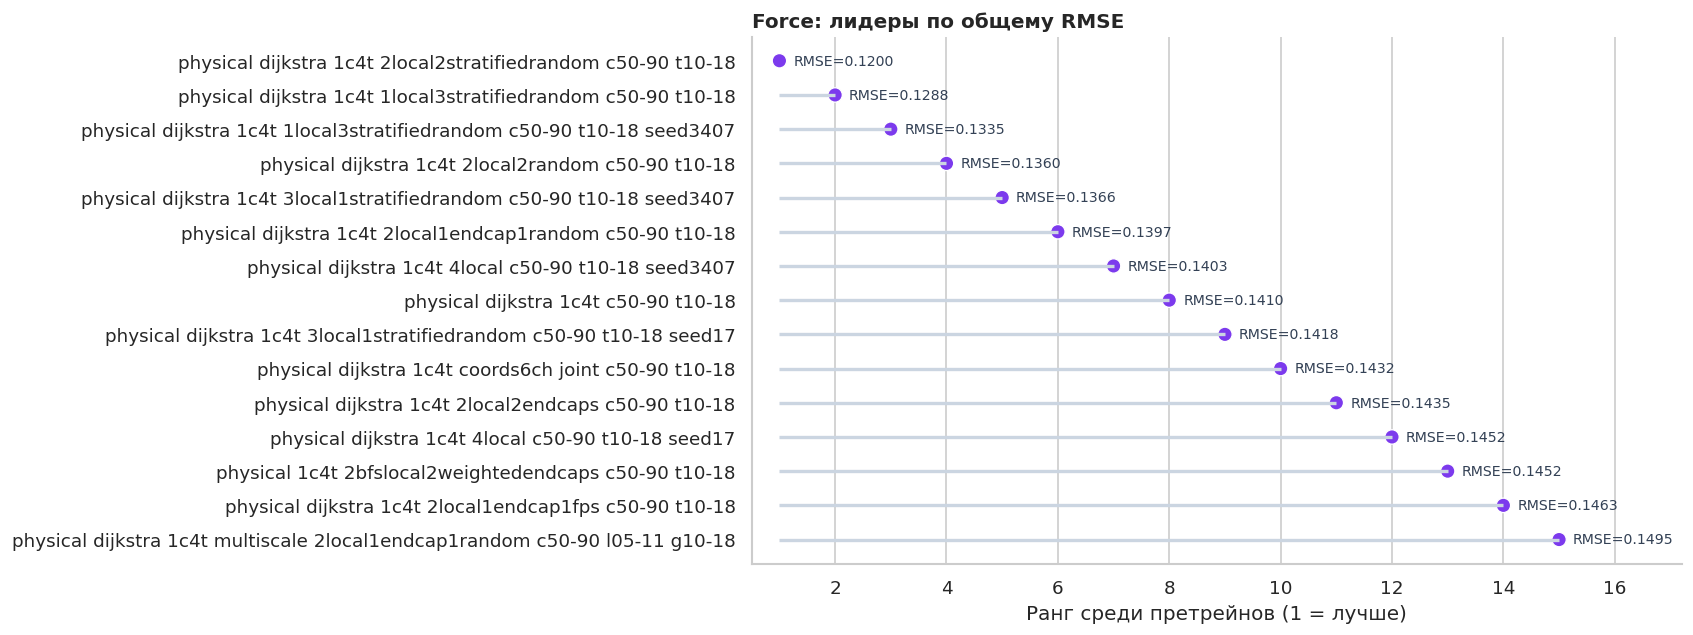

In [4]:
force_cols = ["force_rank", "label", "family", "force_rmse", "force_rmse_x", "force_rmse_y", "force_rmse_z"]
force_top = pre.nsmallest(10, "force_rank")[force_cols].rename(columns={
    "force_rank": "Место",
    "label": "Метод",
    "family": "Семейство",
    "force_rmse": "RMSE",
    "force_rmse_x": "RMSE x",
    "force_rmse_y": "RMSE y",
    "force_rmse_z": "RMSE z",
})
display(styled_table(
    force_top,
    formats={"Место": "{:.0f}", "RMSE": "{:.4f}", "RMSE x": "{:.4f}", "RMSE y": "{:.4f}", "RMSE z": "{:.4f}"},
    gradient_cols=["Место"],
))

rank_dotplot(pre, "force_rank", "force_rmse", "Force: лидеры по общему RMSE", "RMSE={:.4f}", top_n=15)
plt.show()

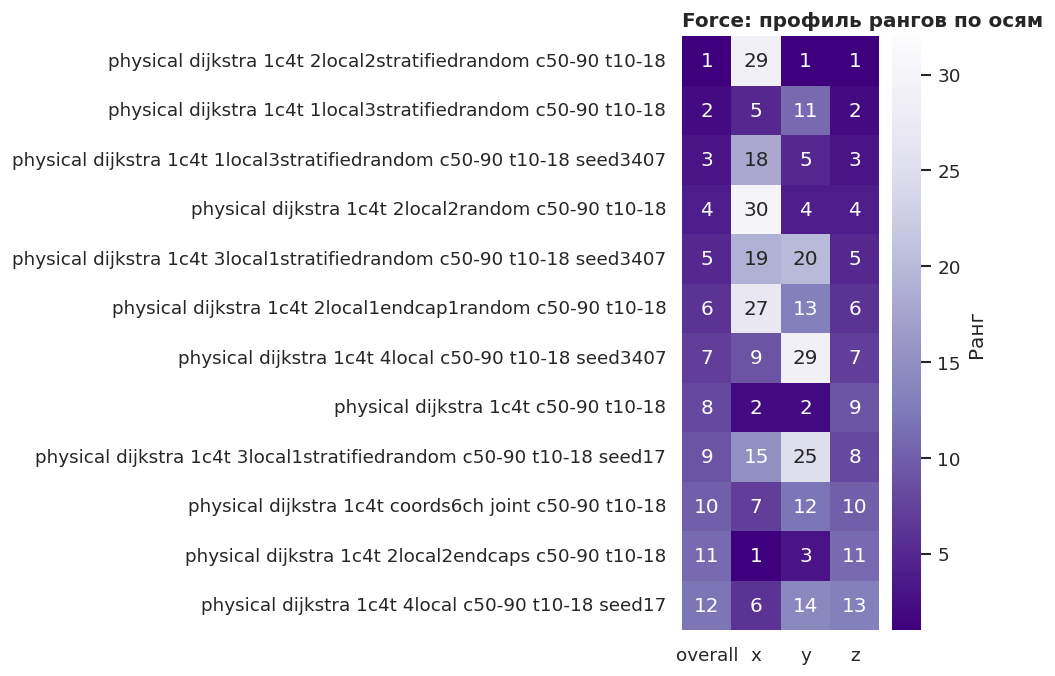

In [5]:
force_heat = (
    pre.nsmallest(12, "force_rank")
    .set_index("label")[["rank_force_rmse", "rank_force_rmse_x", "rank_force_rmse_y", "rank_force_rmse_z"]]
    .rename(columns={
        "rank_force_rmse": "overall",
        "rank_force_rmse_x": "x",
        "rank_force_rmse_y": "y",
        "rank_force_rmse_z": "z",
    })
)
plt.figure(figsize=(8, 5.8))
sns.heatmap(force_heat, annot=True, fmt=".0f", cmap="Purples_r", vmin=1, vmax=n_methods, cbar_kws={"label": "Ранг"})
plt.title("Force: профиль рангов по осям", loc="left")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

---

# 2. Pose estimation

Pose разделён на две способности:

- **translation** — средний ранг по RMSE и accuracy для `x/y`;
- **rotation** — средний ранг по RMSE и accuracy для `θ`.

Итоговый pose rank даёт translation и rotation одинаковый вес.

In [6]:
pose_cols = [
    "pose_rank", "label", "family", "translation_rank", "rotation_rank",
    "pose_rmse_x", "pose_rmse_y", "pose_rmse_theta",
    "pose_acc_x", "pose_acc_y", "pose_acc_theta",
]
pose_top = pre.nsmallest(12, "pose_rank")[pose_cols].rename(columns={
    "pose_rank": "Pose место",
    "label": "Метод",
    "family": "Семейство",
    "translation_rank": "XY место",
    "rotation_rank": "θ место",
    "pose_rmse_x": "RMSE x",
    "pose_rmse_y": "RMSE y",
    "pose_rmse_theta": "RMSE θ",
    "pose_acc_x": "Acc x",
    "pose_acc_y": "Acc y",
    "pose_acc_theta": "Acc θ",
})
display(styled_table(
    pose_top,
    formats={
        "Pose место": "{:.0f}", "XY место": "{:.0f}", "θ место": "{:.0f}",
        "RMSE x": "{:.4f}", "RMSE y": "{:.4f}", "RMSE θ": "{:.3f}",
        "Acc x": "{:.3f}", "Acc y": "{:.3f}", "Acc θ": "{:.3f}",
    },
    gradient_cols=["Pose место", "XY место", "θ место"],
))

Pose место,Метод,Семейство,XY место,θ место,RMSE x,RMSE y,RMSE θ,Acc x,Acc y,Acc θ
1,physical dijkstra 1c4t fresh random192 c50-90 t10-18,Graph JEPA,1,2,0.0086,0.0094,5.221,0.963,0.960,0.728
2,physical dijkstra 1c4t coords separate patch c50-90 t10-18,Graph JEPA,2,5,0.0094,0.0101,5.804,0.955,0.945,0.687
2,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18,Graph JEPA,3,4,0.0099,0.0097,5.866,0.946,0.953,0.702
4,physical dijkstra 1c4t 4stratifiedrandom c50-90 t10-18,Graph JEPA,7,2,0.0097,0.0113,5.501,0.959,0.915,0.731
5,physical dijkstra 1c4t 2local2endcaps c50-90 t10-18 no-taxel,Graph JEPA,9,3,0.0104,0.0109,5.740,0.933,0.921,0.717
6,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,10,8,0.0111,0.0102,6.158,0.921,0.936,0.670
7,physical dijkstra 1c4t 4local c50-90 t10-18 seed3407,Graph JEPA,5,14,0.0104,0.0098,6.382,0.936,0.950,0.654
8,physical dijkstra 1c4t 1local2endcaps1random c50-90 t10-18,Graph JEPA,16,6,0.0115,0.0113,6.204,0.922,0.917,0.709
9,physical dijkstra 1c2t c50-80 t10-22,Graph JEPA,6,19,0.0106,0.0104,6.659,0.945,0.934,0.647
10,physical 1c4t 2bfslocal2weightedendcaps c50-90 t10-18,Graph JEPA,18,8,0.0111,0.0118,6.408,0.933,0.914,0.693


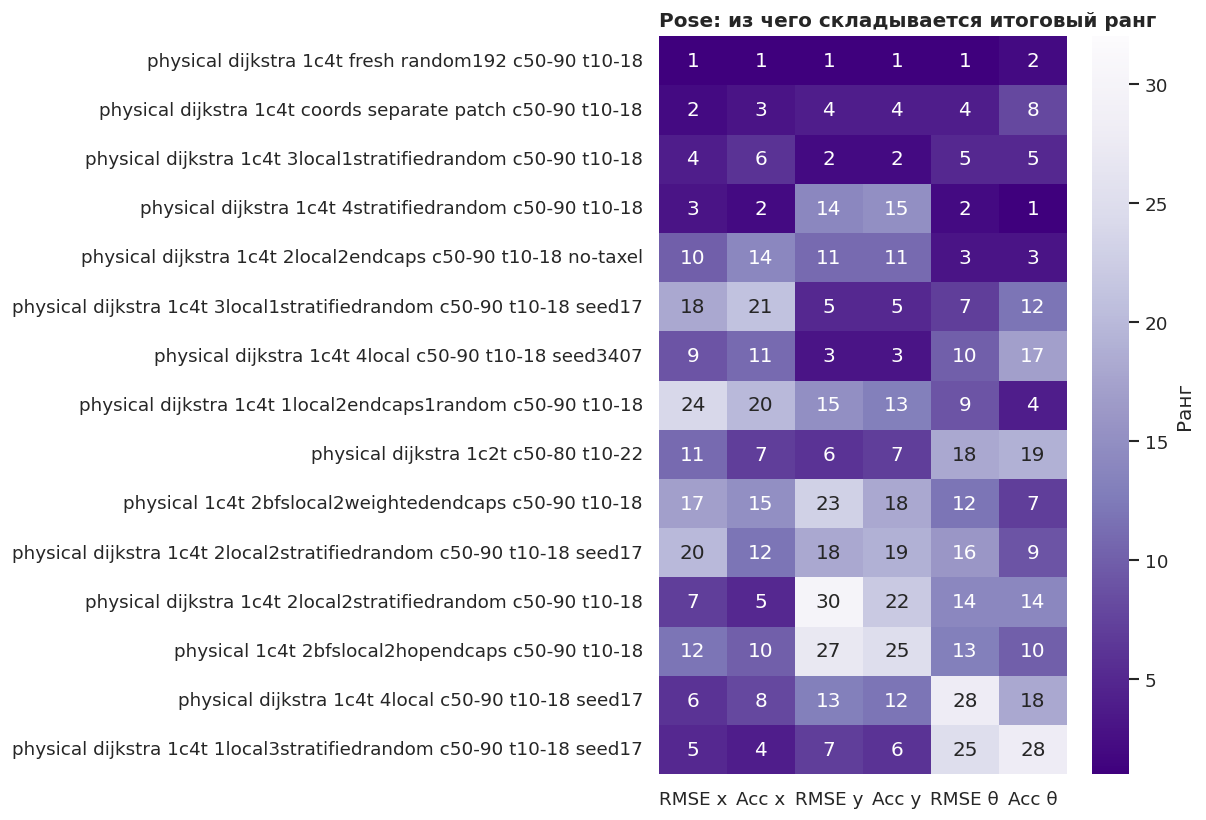

In [7]:
pose_heat_cols = [
    "rank_pose_rmse_x", "rank_pose_acc_x", "rank_pose_rmse_y",
    "rank_pose_acc_y", "rank_pose_rmse_theta", "rank_pose_acc_theta",
]
pose_heat = (
    pre.nsmallest(15, "pose_rank")
    .set_index("label")[pose_heat_cols]
    .rename(columns={
        "rank_pose_rmse_x": "RMSE x",
        "rank_pose_acc_x": "Acc x",
        "rank_pose_rmse_y": "RMSE y",
        "rank_pose_acc_y": "Acc y",
        "rank_pose_rmse_theta": "RMSE θ",
        "rank_pose_acc_theta": "Acc θ",
    })
)
plt.figure(figsize=(10, 7))
sns.heatmap(pose_heat, annot=True, fmt=".0f", cmap="Purples_r", vmin=1, vmax=n_methods, cbar_kws={"label": "Ранг"})
plt.title("Pose: из чего складывается итоговый ранг", loc="left")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

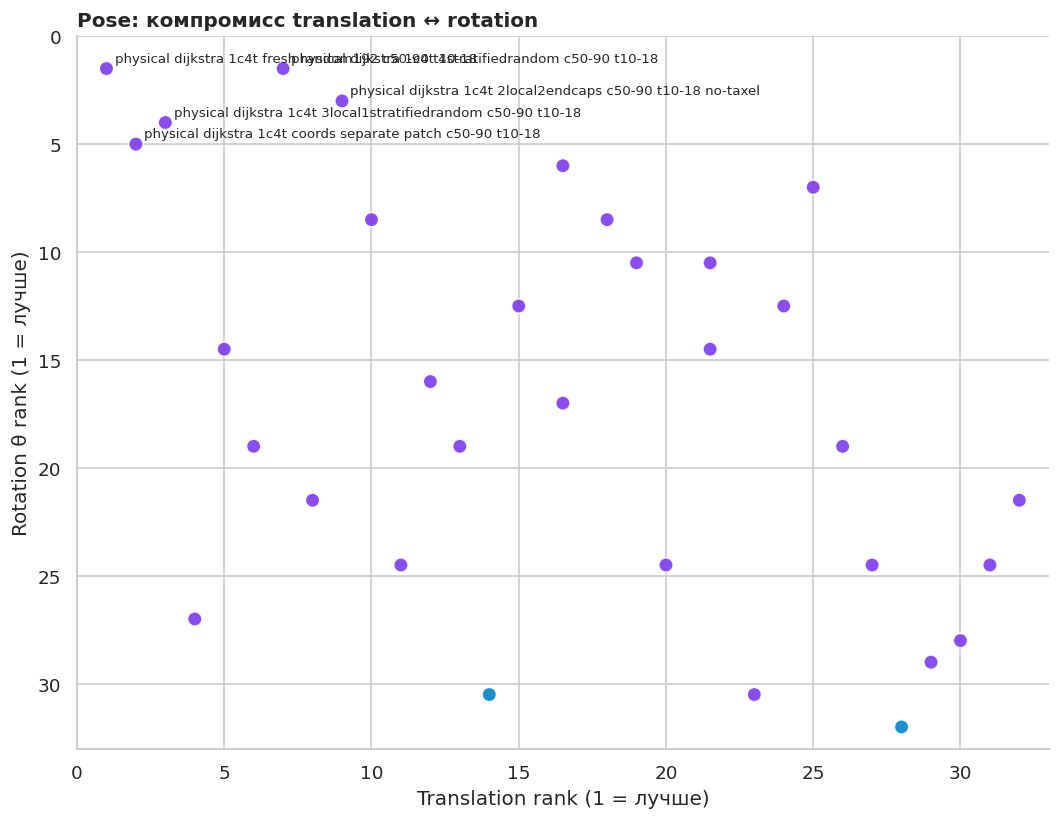

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    pre["translation_rank"], pre["rotation_rank"],
    c=family_colors(pre), s=75, alpha=0.9, edgecolor="white",
)
to_label = pd.concat([
    pre.nsmallest(5, "pose_rank"),
    pre.nsmallest(3, "translation_rank"),
    pre.nsmallest(3, "rotation_rank"),
]).drop_duplicates("method")
for _, row in to_label.iterrows():
    ax.annotate(row["label"], (row["translation_rank"], row["rotation_rank"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Translation rank (1 = лучше)")
ax.set_ylabel("Rotation θ rank (1 = лучше)")
ax.set_title("Pose: компромисс translation ↔ rotation", loc="left")
ax.set_xlim(0, n_methods + 1)
ax.set_ylim(0, n_methods + 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

# 3. Object classification

Object classification — наиболее глобальная задача: для неё особенно важно объединить
контакты по всей руке в одно представление.

Место,Метод,Семейство,Accuracy
1,physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18 seed3407,Graph JEPA,93.420%
2,physical dijkstra 1c4t 2local1endcap1random c50-90 t10-18,Graph JEPA,93.256%
3,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18,Graph JEPA,92.548%
4,physical dijkstra 1c4t 2local1endcap1fps c50-90 t10-18,Graph JEPA,90.570%
5,physical dijkstra 1c4t 1local3stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,88.776%
6,physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18,Graph JEPA,88.751%
7,physical dijkstra 1c4t c50-90 t10-18,Graph JEPA,88.739%
8,physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,87.939%
9,physical dijkstra 1c4t 2local2corridor c50-90 t10-18,Graph JEPA,87.848%
10,physical dijkstra 1c4t multiscale 2local2endcaps c50-90 l05-11 g10-18,Graph JEPA,87.695%


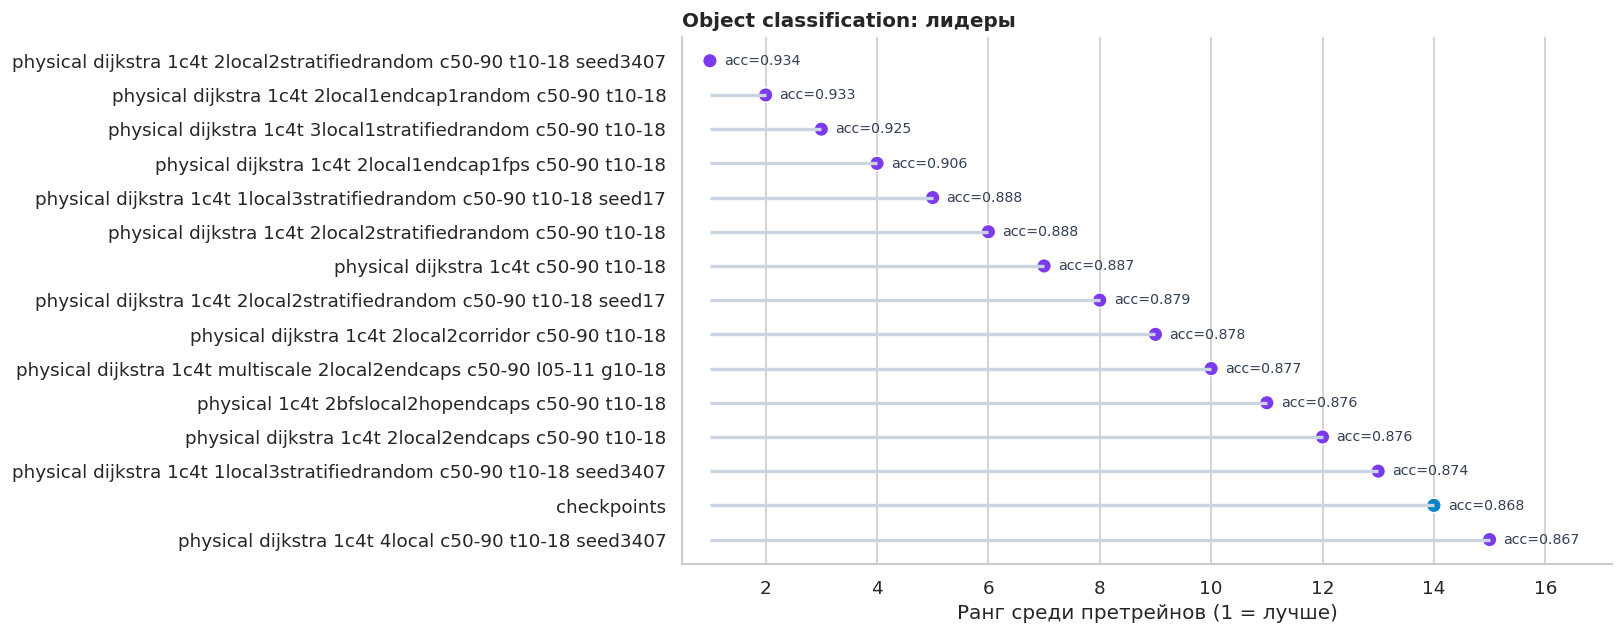

In [9]:
object_cols = ["object_rank", "label", "family", "object_acc"]
object_top = pre.nsmallest(12, "object_rank")[object_cols].rename(columns={
    "object_rank": "Место",
    "label": "Метод",
    "family": "Семейство",
    "object_acc": "Accuracy",
})
display(styled_table(
    object_top,
    formats={"Место": "{:.0f}", "Accuracy": "{:.3%}"},
    gradient_cols=["Место"],
))

rank_dotplot(pre, "object_rank", "object_acc", "Object classification: лидеры", "acc={:.3f}", top_n=15)
plt.show()

---

# 4. От локального к глобальному

Используем четыре последовательных уровня:

1. `Force` — локальный контакт;
2. `Pose XY` — взаимное положение и распределение контакта;
3. `Pose θ` — глобальная ориентация;
4. `Object` — глобальная семантика объекта.

Чем ниже линия, тем лучше место. Плоская низкая линия означает универсальный претрейн;
резкий наклон показывает специализацию.

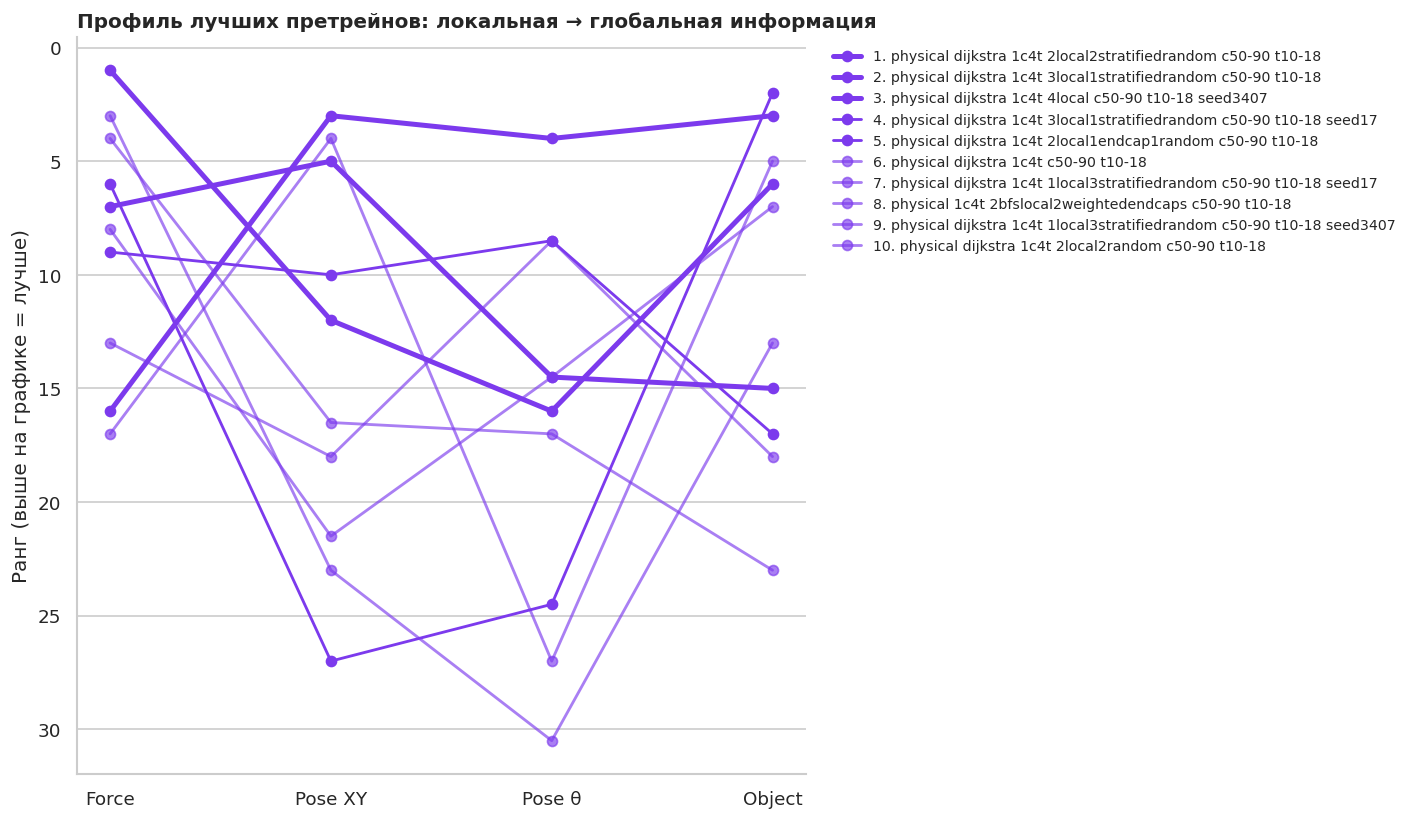

In [10]:
profile_cols = ["force_rank", "translation_rank", "rotation_rank", "object_rank"]
profile_names = ["Force", "Pose XY", "Pose θ", "Object"]
profile_methods = pre.nsmallest(10, "overall_rank").copy()

fig, ax = plt.subplots(figsize=(12, 7))
for _, row in profile_methods.iterrows():
    values = row[profile_cols].to_numpy(float)
    color = COLORS[row["family"]]
    linewidth = 3 if row["overall_rank"] <= 3 else 1.7
    alpha = 1.0 if row["overall_rank"] <= 5 else 0.65
    ax.plot(profile_names, values, marker="o", linewidth=linewidth, alpha=alpha,
            color=color, label=f'{int(row["overall_rank"])}. {row["label"]}')
ax.invert_yaxis()
ax.set_ylabel("Ранг (выше на графике = лучше)")
ax.set_title("Профиль лучших претрейнов: локальная → глобальная информация", loc="left")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8.5)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

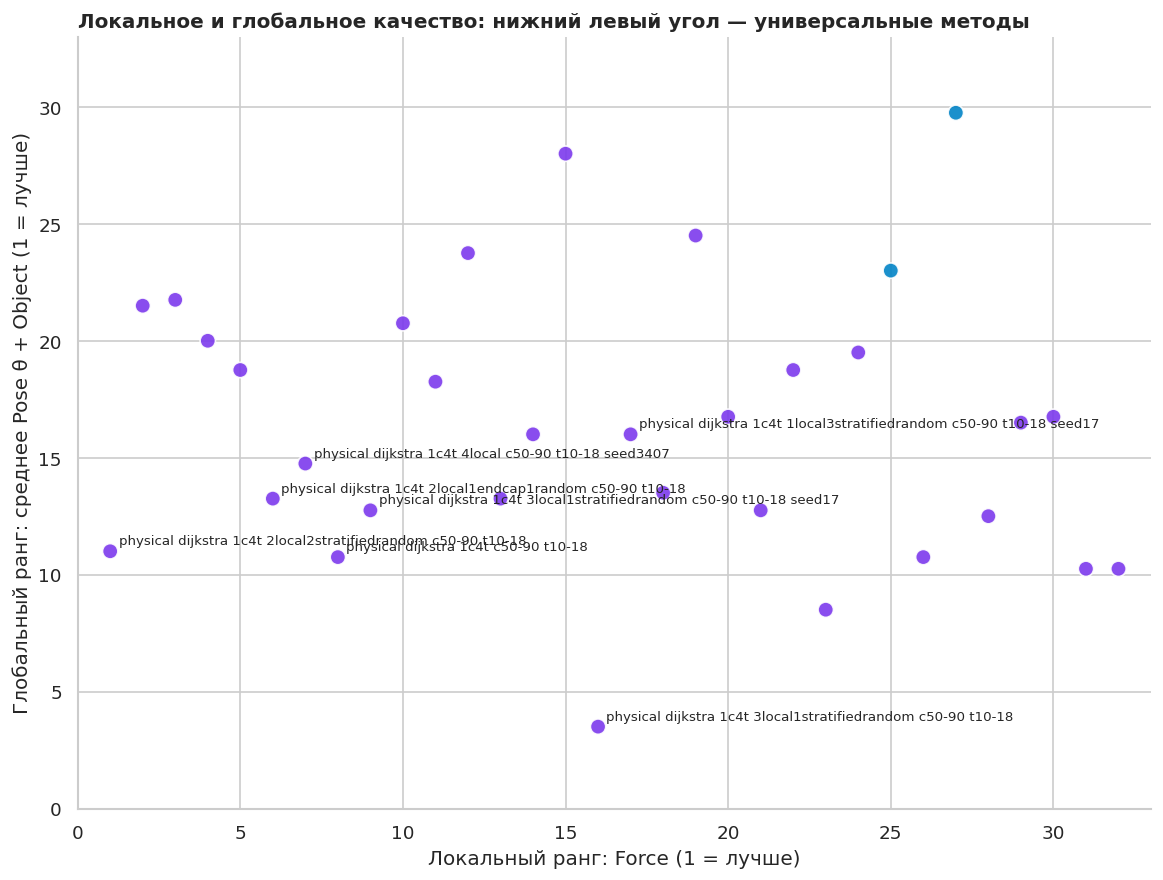

**Парето-фронт local/global:** physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18, physical dijkstra 1c4t c50-90 t10-18, physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18

In [11]:
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(
    pre["force_rank"], pre["global_mean_rank"],
    c=family_colors(pre), s=85, alpha=0.9, edgecolor="white",
)

front = pre[pareto_mask(pre, ["force_rank", "global_mean_rank"])].copy()
to_label = pd.concat([
    front,
    pre.nsmallest(7, "overall_rank"),
]).drop_duplicates("method")
for _, row in to_label.iterrows():
    ax.annotate(row["label"], (row["force_rank"], row["global_mean_rank"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel("Локальный ранг: Force (1 = лучше)")
ax.set_ylabel("Глобальный ранг: среднее Pose θ + Object (1 = лучше)")
ax.set_title("Локальное и глобальное качество: нижний левый угол — универсальные методы", loc="left")
ax.set_xlim(0, n_methods + 1)
ax.set_ylim(0, n_methods + 1)
plt.tight_layout()
plt.show()

display(Markdown("**Парето-фронт local/global:** " + ", ".join(front.sort_values("force_rank")["label"])))

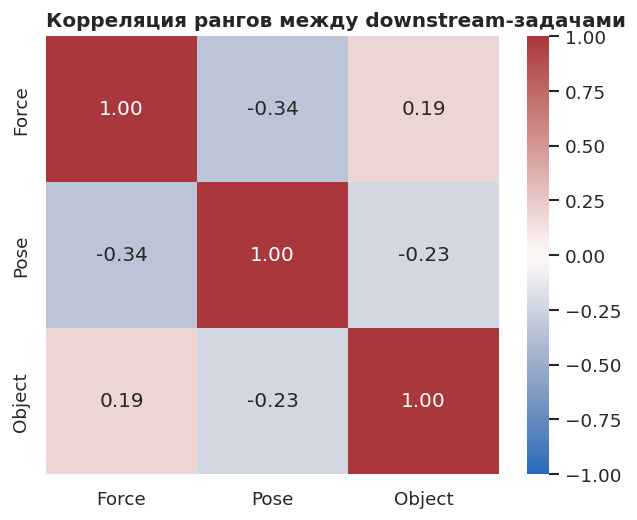

In [12]:
rank_corr = pre[["force_rank", "pose_rank", "object_rank"]].corr(method="spearman")
rank_corr.index = ["Force", "Pose", "Object"]
rank_corr.columns = ["Force", "Pose", "Object"]

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(rank_corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Корреляция рангов между downstream-задачами", loc="left")
plt.tight_layout()
plt.show()

---

# 5. Общий топ

Основной итог — **средний ранг по трём downstream-задачам с равными весами**.
Рядом показан worst-task rank: насколько плохо метод может выступить на своей слабейшей задаче.

In [13]:
overall_cols = [
    "overall_rank", "label", "family", "force_rank", "pose_rank", "object_rank",
    "overall_mean_rank", "worst_task_rank", "overall_score_100",
]
overall = pre.sort_values(["overall_rank", "worst_task_rank"])[overall_cols].rename(columns={
    "overall_rank": "Общее место",
    "label": "Метод",
    "family": "Семейство",
    "force_rank": "Force",
    "pose_rank": "Pose",
    "object_rank": "Object",
    "overall_mean_rank": "Средний ранг",
    "worst_task_rank": "Худший ранг",
    "overall_score_100": "Rank score / 100",
})
display(styled_table(
    overall.head(15),
    formats={
        "Общее место": "{:.0f}", "Force": "{:.0f}", "Pose": "{:.0f}", "Object": "{:.0f}",
        "Средний ранг": "{:.2f}", "Худший ранг": "{:.0f}", "Rank score / 100": "{:.1f}",
    },
    gradient_cols=["Общее место", "Force", "Pose", "Object", "Худший ранг"],
))

Общее место,Метод,Семейство,Force,Pose,Object,Средний ранг,Худший ранг,Rank score / 100
1,physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18,Graph JEPA,1,12,6,6.33,12,82.8
2,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18,Graph JEPA,16,2,3,7.17,16,80.1
3,physical dijkstra 1c4t 4local c50-90 t10-18 seed3407,Graph JEPA,7,7,15,9.67,15,72.0
4,physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,9,6,17,10.67,17,68.8
5,physical dijkstra 1c4t 2local1endcap1random c50-90 t10-18,Graph JEPA,6,26,2,11.33,26,66.7
6,physical dijkstra 1c4t c50-90 t10-18,Graph JEPA,8,21,7,12.00,21,64.5
7,physical dijkstra 1c4t 1local3stratifiedrandom c50-90 t10-18 seed17,Graph JEPA,17,15,5,12.33,17,63.4
8,physical 1c4t 2bfslocal2weightedendcaps c50-90 t10-18,Graph JEPA,13,10,18,13.67,18,59.1
9,physical dijkstra 1c4t 1local3stratifiedrandom c50-90 t10-18 seed3407,Graph JEPA,3,28,13,14.50,28,56.5
10,physical dijkstra 1c4t 2local2random c50-90 t10-18,Graph JEPA,4,19,23,15.33,23,53.8


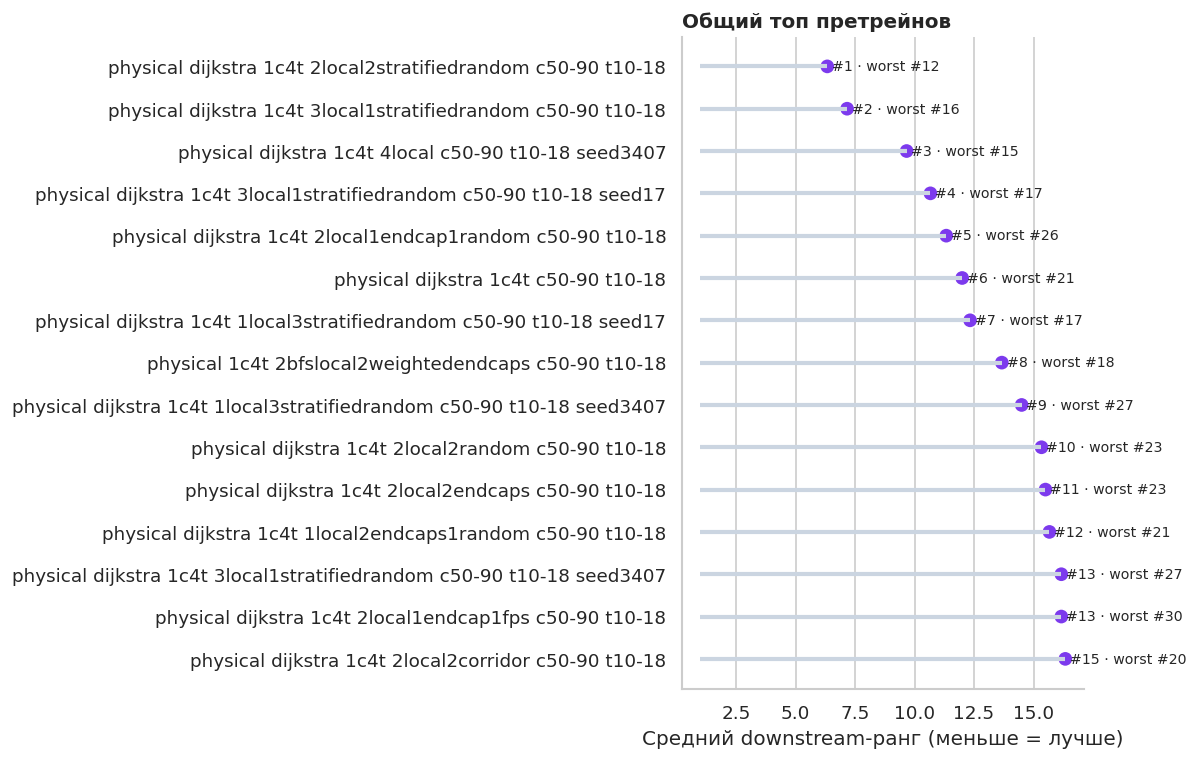

In [14]:
top = pre.nsmallest(15, "overall_rank").sort_values("overall_rank", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.hlines(top["label"], 1, top["overall_mean_rank"], color="#CBD5E1", linewidth=2.5)
ax.scatter(
    top["overall_mean_rank"], top["label"],
    c=family_colors(top), s=85, edgecolor="white",
)
for _, row in top.iterrows():
    ax.text(row["overall_mean_rank"] + 0.2, row["label"],
            f'#{int(row["overall_rank"])} · worst #{int(row["worst_task_rank"])}',
            va="center", fontsize=8.5)
ax.set_xlabel("Средний downstream-ранг (меньше = лучше)")
ax.set_ylabel("")
ax.set_title("Общий топ претрейнов", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

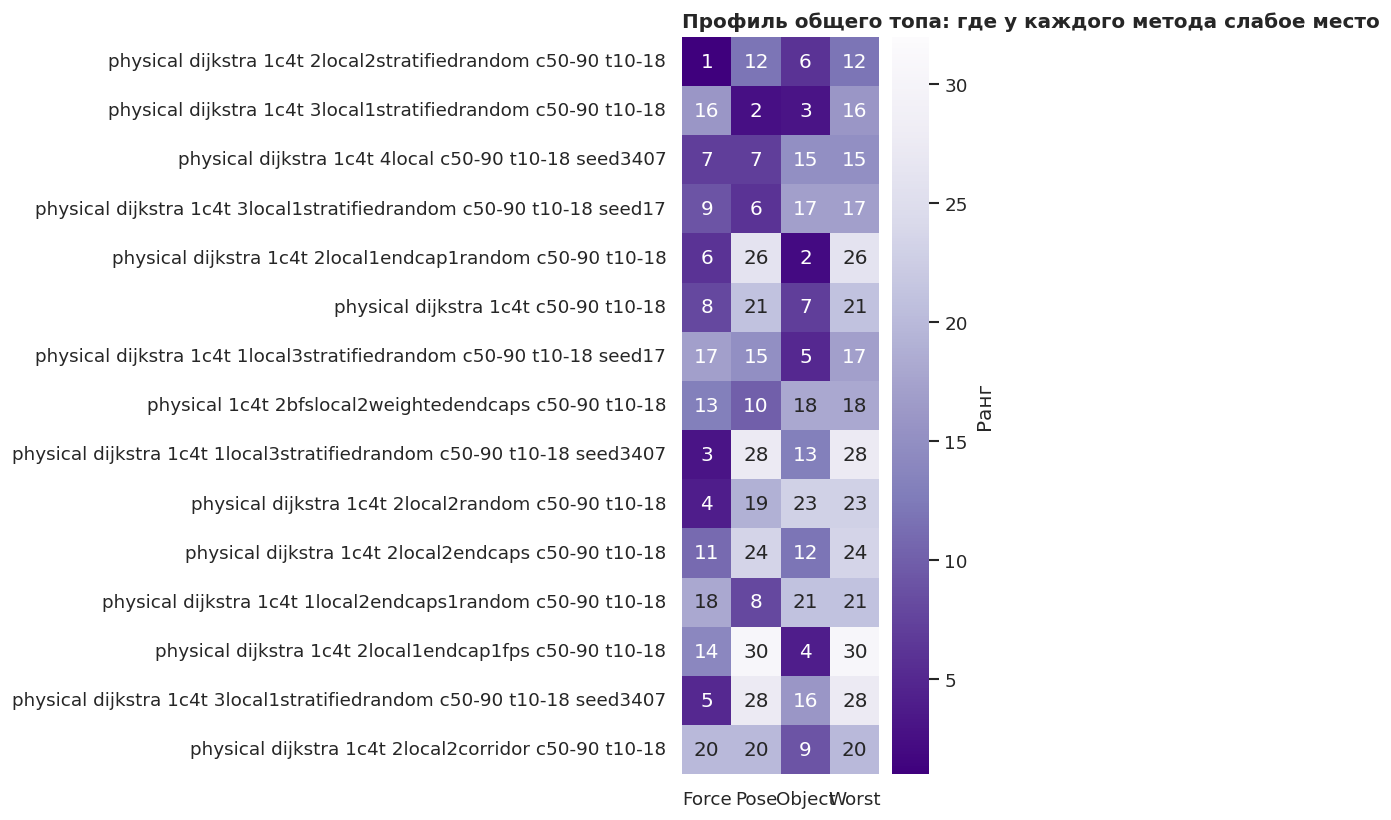

In [15]:
top_heat = (
    pre.nsmallest(15, "overall_rank")
    .set_index("label")[["force_rank", "pose_rank", "object_rank", "worst_task_rank"]]
    .rename(columns={
        "force_rank": "Force",
        "pose_rank": "Pose",
        "object_rank": "Object",
        "worst_task_rank": "Worst",
    })
)
plt.figure(figsize=(8, 7))
sns.heatmap(top_heat, annot=True, fmt=".0f", cmap="Purples_r", vmin=1, vmax=n_methods, cbar_kws={"label": "Ранг"})
plt.title("Профиль общего топа: где у каждого метода слабое место", loc="left")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [16]:
winner = pre.nsmallest(1, "overall_rank").iloc[0]
force_winner = pre.nsmallest(1, "force_rank").iloc[0]
pose_winner = pre.nsmallest(1, "pose_rank").iloc[0]
object_winner = pre.nsmallest(1, "object_rank").iloc[0]
robust = pre.sort_values(["worst_task_rank", "overall_mean_rank"]).iloc[0]
pareto3 = pre[pareto_mask(pre, ["force_rank", "pose_rank", "object_rank"])].sort_values("overall_rank")

display(Markdown(f'''
## Автоматически рассчитанные выводы

- **Общий победитель по среднему рангу:** `{winner.label}` —
  средний ранг {winner.overall_mean_rank:.2f}, худшее место #{winner.worst_task_rank:.0f}.
- **Лучший Force:** `{force_winner.label}` — RMSE {force_winner.force_rmse:.4f}.
- **Лучший Pose:** `{pose_winner.label}` — translation #{pose_winner.translation_rank:.0f},
  rotation #{pose_winner.rotation_rank:.0f}.
- **Лучший Object:** `{object_winner.label}` — accuracy {object_winner.object_acc:.3%}.
- **Minimax-победитель:** `{robust.label}` — его худшая задача имеет ранг
  #{robust.worst_task_rank:.0f}.
- **Трёхмерный Парето-фронт Force/Pose/Object:**  
  {", ".join(pareto3.label)}

Ранговый топ отвечает на вопрос «кто универсальнее в текущем наборе экспериментов».
Он не показывает статистическую значимость небольших различий и должен обновляться после
добавления новых seed или новых претрейнов.
'''))


## Автоматически рассчитанные выводы

- **Общий победитель по среднему рангу:** `physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18` —
  средний ранг 6.33, худшее место #12.
- **Лучший Force:** `physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18` — RMSE 0.1200.
- **Лучший Pose:** `physical dijkstra 1c4t fresh random192 c50-90 t10-18` — translation #1,
  rotation #2.
- **Лучший Object:** `physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18 seed3407` — accuracy 93.420%.
- **Minimax-победитель:** `physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18` — его худшая задача имеет ранг
  #12.
- **Трёхмерный Парето-фронт Force/Pose/Object:**  
  physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18, physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18, physical dijkstra 1c4t 4local c50-90 t10-18 seed3407, physical dijkstra 1c4t 3local1stratifiedrandom c50-90 t10-18 seed17, physical dijkstra 1c4t 2local1endcap1random c50-90 t10-18, physical dijkstra 1c4t fresh random192 c50-90 t10-18, physical dijkstra 1c4t 2local2stratifiedrandom c50-90 t10-18 seed3407

Ранговый топ отвечает на вопрос «кто универсальнее в текущем наборе экспериментов».
Он не показывает статистическую значимость небольших различий и должен обновляться после
добавления новых seed или новых претрейнов.


## Ограничения анализа

- Сейчас большинство строк представлены одним seed; ранг не равен статистической уверенности.
- Ранги зависят от состава таблицы: добавление новых методов может изменить номера мест,
  даже если абсолютные метрики старых методов не изменились.
- Overall rank специально даёт одинаковый вес downstream-задачам. Если бизнес-приоритеты
  другие, веса следует менять явно, а не скрыто через число метрик.
- Для финального выбора разумно повторить top-3 минимум на трёх seed и ранжировать уже
  средние значения вместе с неопределённостью.